In [37]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

In [38]:
ds = pd.read_csv('nibss_fraud_dataset.csv', on_bad_lines='skip')
ds.head()

,transaction_id,customer_id,timestamp,amount,channel,merchant_category,bank,location,age_group,hour,...,hour_cos,day_sin,day_cos,month_sin,month_cos,amount_log,amount_rounded,velocity_score,merchant_risk_score,composite_risk
0,TXN_F08A86FFD87C,CUST_0002AED1,2023-01-14 04:31:09,32266.83,Mobile,Grocery,Sterling,Other,30-39,4,...,0.500000,-0.974928,-0.222521,0.500000,0.866025,10.381826,0,0.189369,0.215000,0.070560
1,TXN_C2D08134EC83,CUST_0002AED1,2023-01-17 11:20:13,72530.49,Web,Entertainment,UBA,Other,30-39,11,...,-0.965926,0.781831,0.623490,0.500000,0.866025,11.191776,0,0.425671,0.877424,0.276849
2,TXN_B9499111901D,CUST_0002AED1,2023-01-22 02:17:46,168152.87,Mobile,Transport,Wema,Other,30-39,2,...,0.866025,-0.781831,0.623490,0.500000,0.866025,12.032635,0,0.986866,0.440230,0.163649
3,TXN_48DB1D526A3B,CUST_0002AED1,2023-01-24 08:18:23,16439.93,Mobile,Entertainment,FCMB,Other,30-39,8,...,-0.500000,0.781831,0.623490,0.500000,0.866025,9.707529,0,0.096484,0.877424,0.266315
4,TXN_56DB1E28B758,CUST_0002AED1,2023-02-01 15:39:53,9922.68,POS,Education,FirstBank,Other,30-39,15,...,-0.707107,0.974928,-0.222521,0.866025,0.500000,9.202679,0,0.058235,0.231291,0.071251


In [39]:
ds.describe()

,amount,hour,day_of_week,month,tx_count_24h,amount_sum_24h,amount_mean_7d,amount_std_7d,tx_count_total,amount_mean_total,...,hour_cos,day_sin,day_cos,month_sin,month_cos,amount_log,amount_rounded,velocity_score,merchant_risk_score,composite_risk
count,1.000000e+06,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1.000000e+06,1.000000e+06,1.000000e+06,1000000.000000,1000000.000000,...,1000000.000000,1000000.000000,1000000.000000,1.000000e+06,1.000000e+06,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,1.569514e+05,12.228639,3.013070,6.609283,1.282159,1.991769e+05,1.557863e+05,1.112951e+05,100.985146,156224.102273,...,-0.466445,-0.001601,-0.003539,3.397843e-02,1.272586e-02,11.110517,0.000079,1.905117,0.395645,0.151286
std,3.263590e+05,4.798625,1.997767,3.464179,0.533265,3.742924e+05,2.184174e+05,2.091671e+05,9.900881,32450.494993,...,0.589371,0.707580,0.706623,7.197222e-01,6.933142e-01,1.302152,0.008888,3.915378,0.238704,0.087124
min,1.685500e+02,0.000000,0.000000,1.000000,1.000000,1.685500e+02,2.128300e+02,0.000000e+00,61.000000,79531.073708,...,-1.000000,-0.974928,-0.900969,-1.000000e+00,-1.000000e+00,5.133148,0.000000,0.001077,0.121274,0.036431
25%,2.800042e+04,9.000000,1.000000,3.000000,1.000000,3.617210e+04,5.327417e+04,1.421574e+04,94.000000,133244.011525,...,-0.866025,-0.781831,-0.900969,-5.000000e-01,-5.000000e-01,10.240010,0.000000,0.246675,0.202718,0.078078
50%,6.667998e+04,12.000000,3.000000,7.000000,1.000000,8.971861e+04,9.779375e+04,5.121962e+04,101.000000,151366.221635,...,-0.707107,0.000000,-0.222521,-2.449294e-16,6.123234e-17,11.107675,0.000000,0.681163,0.369588,0.135629
75%,1.595289e+05,15.000000,5.000000,10.000000,1.000000,2.150990e+05,1.795145e+05,1.246082e+05,107.000000,174289.988391,...,-0.258819,0.781831,0.623490,8.660254e-01,5.000000e-01,11.979987,0.000000,1.915726,0.542436,0.196458
max,1.792681e+07,23.000000,6.000000,12.000000,6.000000,1.326406e+07,1.000000e+07,4.998794e+06,140.000000,380508.803514,...,1.000000,0.974928,1.000000,1.000000e+00,1.000000e+00,16.701808,1.000000,191.519506,0.877424,0.734583


In [40]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 38 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   transaction_id        1000000 non-null  object 
 1   customer_id           1000000 non-null  object 
 2   timestamp             1000000 non-null  object 
 3   amount                1000000 non-null  float64
 4   channel               1000000 non-null  object 
 5   merchant_category     1000000 non-null  object 
 6   bank                  1000000 non-null  object 
 7   location              1000000 non-null  object 
 8   age_group             1000000 non-null  object 
 9   hour                  1000000 non-null  int64  
 10  day_of_week           1000000 non-null  int64  
 11  month                 1000000 non-null  int64  
 12  is_weekend            1000000 non-null  bool   
 13  is_peak_hour          1000000 non-null  bool   
 14  tx_count_24h          1000000 non-n

In [41]:
ds.columns

Index(['transaction_id', 'customer_id', 'timestamp', 'amount', 'channel',
       'merchant_category', 'bank', 'location', 'age_group', 'hour',
       'day_of_week', 'month', 'is_weekend', 'is_peak_hour', 'tx_count_24h',
       'amount_sum_24h', 'amount_mean_7d', 'amount_std_7d', 'tx_count_total',
       'amount_mean_total', 'amount_std_total', 'channel_diversity',
       'location_diversity', 'amount_vs_mean_ratio', 'online_channel_ratio',
       'is_fraud', 'fraud_technique', 'hour_sin', 'hour_cos', 'day_sin',
       'day_cos', 'month_sin', 'month_cos', 'amount_log', 'amount_rounded',
       'velocity_score', 'merchant_risk_score', 'composite_risk'],
      dtype='object')

In [42]:
ds.shape

(1000000, 38)

In [43]:
#Finding the missing values.
ds.isnull().sum()

transaction_id               0
customer_id                  0
timestamp                    0
amount                       0
channel                      0
merchant_category            0
bank                         0
location                     0
age_group                    0
hour                         0
day_of_week                  0
month                        0
is_weekend                   0
is_peak_hour                 0
tx_count_24h                 0
amount_sum_24h               0
amount_mean_7d               0
amount_std_7d                0
tx_count_total               0
amount_mean_total            0
amount_std_total             0
channel_diversity            0
location_diversity           0
amount_vs_mean_ratio         0
online_channel_ratio         0
is_fraud                     0
fraud_technique         997000
hour_sin                     0
hour_cos                     0
day_sin                      0
day_cos                      0
month_sin                    0
month_co

In [44]:
#to replace missing values
for i in ds.columns:
  if ((ds[i].isnull().sum() / len(ds))*100) < 30:
    if ds[i].dtypes != 'O':
      ds[i].fillna(ds[i].median(), inplace=True)
    else:
      ds[i].fillna(ds[i].mode()[0], inplace=True)
  else:
    ds.drop(i, axis =1, inplace=True)
ds.isnull().sum()

transaction_id          0
customer_id             0
timestamp               0
amount                  0
channel                 0
merchant_category       0
bank                    0
location                0
age_group               0
hour                    0
day_of_week             0
month                   0
is_weekend              0
is_peak_hour            0
tx_count_24h            0
amount_sum_24h          0
amount_mean_7d          0
amount_std_7d           0
tx_count_total          0
amount_mean_total       0
amount_std_total        0
channel_diversity       0
location_diversity      0
amount_vs_mean_ratio    0
online_channel_ratio    0
is_fraud                0
hour_sin                0
hour_cos                0
day_sin                 0
day_cos                 0
month_sin               0
month_cos               0
amount_log              0
amount_rounded          0
velocity_score          0
merchant_risk_score     0
composite_risk          0
dtype: int64

In [45]:
#checking for the numerical and categorical data.
numerical_data = ds.select_dtypes(include = ['number'])
categorical_data = ds.select_dtypes(exclude = ['number'])
print('Numerical columns: \n')
display(numerical_data.head())
print('\nCategorical columns:')
display(categorical_data.head())

Numerical columns: 



,amount,hour,day_of_week,month,tx_count_24h,amount_sum_24h,amount_mean_7d,amount_std_7d,tx_count_total,amount_mean_total,...,hour_cos,day_sin,day_cos,month_sin,month_cos,amount_log,amount_rounded,velocity_score,merchant_risk_score,composite_risk
0,32266.83,4,5,1,1.0,32266.83,32266.830000,0.000000,107,170389.868692,...,0.500000,-0.974928,-0.222521,0.500000,0.866025,10.381826,0,0.189369,0.215000,0.070560
1,72530.49,11,1,1,1.0,72530.49,52398.660000,20131.830000,107,170389.868692,...,-0.965926,0.781831,0.623490,0.500000,0.866025,11.191776,0,0.425671,0.877424,0.276849
2,168152.87,2,6,1,1.0,168152.87,120341.680000,47811.190000,107,170389.868692,...,0.866025,-0.781831,0.623490,0.500000,0.866025,12.032635,0,0.986866,0.440230,0.163649
3,16439.93,8,1,1,1.0,16439.93,85707.763333,62633.507753,107,170389.868692,...,-0.500000,0.781831,0.623490,0.500000,0.866025,9.707529,0,0.096484,0.877424,0.266315
4,9922.68,15,2,2,1.0,9922.68,9922.680000,0.000000,107,170389.868692,...,-0.707107,0.974928,-0.222521,0.866025,0.500000,9.202679,0,0.058235,0.231291,0.071251



Categorical columns:


,transaction_id,customer_id,timestamp,channel,merchant_category,bank,location,age_group,is_weekend,is_peak_hour
0,TXN_F08A86FFD87C,CUST_0002AED1,2023-01-14 04:31:09,Mobile,Grocery,Sterling,Other,30-39,True,False
1,TXN_C2D08134EC83,CUST_0002AED1,2023-01-17 11:20:13,Web,Entertainment,UBA,Other,30-39,False,True
2,TXN_B9499111901D,CUST_0002AED1,2023-01-22 02:17:46,Mobile,Transport,Wema,Other,30-39,True,False
3,TXN_48DB1D526A3B,CUST_0002AED1,2023-01-24 08:18:23,Mobile,Entertainment,FCMB,Other,30-39,False,False
4,TXN_56DB1E28B758,CUST_0002AED1,2023-02-01 15:39:53,POS,Education,FirstBank,Other,30-39,False,True


In [46]:
#Finding the correlation
numerical_data.corr()

,amount,hour,day_of_week,month,tx_count_24h,amount_sum_24h,amount_mean_7d,amount_std_7d,tx_count_total,amount_mean_total,...,hour_cos,day_sin,day_cos,month_sin,month_cos,amount_log,amount_rounded,velocity_score,merchant_risk_score,composite_risk
amount,1.000000,0.000623,0.000459,0.069611,-0.005248,0.858618,0.670893,0.485993,-2.517326e-04,9.925681e-02,...,0.001014,-0.000411,0.000543,-0.070839,0.031939,0.632115,0.227217,0.581526,-0.000674,0.496707
hour,0.000623,1.000000,0.001149,0.000090,0.000951,0.001149,0.001689,0.002474,4.287720e-04,4.076280e-04,...,-0.086345,0.000264,-0.000953,0.001423,0.001600,-0.000277,-0.000142,0.001269,-0.000661,-0.000062
day_of_week,0.000459,0.001149,1.000000,0.014383,0.001405,0.000981,0.000461,0.001173,-1.095312e-03,-6.225406e-04,...,0.000723,-0.735209,-0.346901,0.001699,0.008970,-0.000093,0.000899,0.001453,-0.001111,-0.000764
month,0.069611,0.000090,0.014383,1.000000,-0.002300,0.080542,0.102323,0.091160,2.373082e-04,6.510078e-03,...,-0.000740,-0.012562,-0.004373,-0.763456,0.305192,0.118110,0.002042,0.073385,-0.002901,0.048268
tx_count_24h,-0.005248,0.000951,0.001405,-0.002300,1.000000,0.210977,-0.009014,0.078404,5.206690e-02,-1.301454e-03,...,0.001741,-0.000611,-0.005419,0.041604,0.015133,-0.010295,0.000361,0.469229,-0.001698,0.037272
amount_sum_24h,0.858618,0.001149,0.000981,0.080542,0.210977,1.000000,0.685521,0.567523,1.123812e-02,1.092764e-01,...,0.001426,-0.000675,-0.000431,-0.071848,0.038630,0.548564,0.198691,0.856618,-0.000683,0.464532
amount_mean_7d,0.670893,0.001689,0.000461,0.102323,-0.009014,0.685521,1.000000,0.720136,-1.661863e-04,1.472226e-01,...,-0.000331,0.000052,0.001338,-0.103567,0.048419,0.430668,0.165332,0.475965,-0.000574,0.341790
amount_std_7d,0.485993,0.002474,0.001173,0.091160,0.078404,0.567523,0.720136,1.000000,2.830793e-02,1.483561e-01,...,0.000173,-0.000192,-0.002008,-0.065746,0.039282,0.234638,0.131333,0.466491,-0.000807,0.239139
tx_count_total,-0.000252,0.000429,-0.001095,0.000237,0.052067,0.011238,-0.000166,0.028308,1.000000e+00,-8.555348e-04,...,0.000234,0.001034,0.000202,-0.000209,-0.000274,-0.000956,0.000172,0.024623,-0.000342,0.001490
amount_mean_total,0.099257,0.000408,-0.000623,0.006510,-0.001301,0.109276,0.147223,0.148356,-8.555348e-04,1.000000e+00,...,0.000618,0.000963,-0.000876,-0.007087,0.003223,0.063716,0.021623,-0.001105,-0.000528,-0.011498


In [47]:
corr_target = numerical_data.corr()['is_fraud'].sort_values(ascending=False)
print(corr_target)

is_fraud                1.000000
amount_log              0.044477
amount                  0.038324
month_sin               0.003174
day_cos                 0.001844
day_of_week             0.001618
amount_rounded          0.001570
online_channel_ratio    0.001326
amount_std_total        0.000839
hour_cos                0.000832
hour                   -0.000011
amount_mean_total      -0.000262
merchant_risk_score    -0.000635
hour_sin               -0.000752
channel_diversity      -0.000788
tx_count_total         -0.001070
tx_count_24h           -0.001114
day_sin                -0.001682
amount_sum_24h         -0.001903
velocity_score         -0.001939
composite_risk         -0.001940
amount_vs_mean_ratio   -0.002384
amount_std_7d          -0.002457
amount_mean_7d         -0.002478
month_cos              -0.006485
month                  -0.011173
location_diversity           NaN
Name: is_fraud, dtype: float64


In [48]:
important_features = corr_target[abs(corr_target) > 0.05].index

<Axes: >

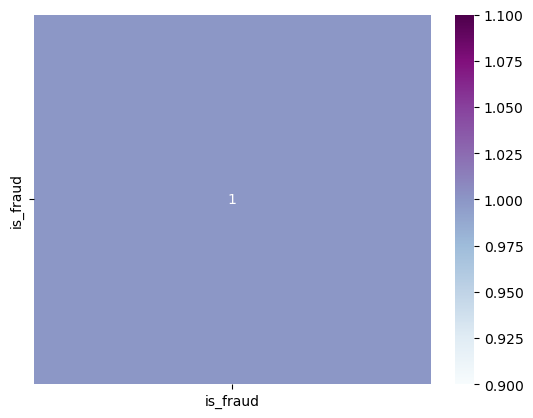

In [49]:
columns_to_plot = important_features.tolist()
if 'is_fraud' not in columns_to_plot:
    columns_to_plot.append('is_fraud')

correlation_matrix_subset = numerical_data[columns_to_plot].corr()
sns.heatmap(correlation_matrix_subset, annot=True, cmap='BuPu')

In [50]:
#Checking for duplicates
Data_duplicates = ds.duplicated()
Data_duplicates.sum()

np.int64(0)

In [51]:
from sklearn.preprocessing import LabelEncoder
import joblib

# Select categorical columns
categorical_cols = ds.select_dtypes(include='object').columns.tolist()

encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    ds[col] = le.fit_transform(ds[col])
    encoders[col] = le   # Save the fitted encoder for this column

# Save all encoders in one file
joblib.dump(encoders, 'encoders.joblib')

print(f"Encoded {len(categorical_cols)} categorical columns")
print("Saved encoders for:", list(encoders.keys()))
ds.head()

Encoded 8 categorical columns
Saved encoders for: ['transaction_id', 'customer_id', 'timestamp', 'channel', 'merchant_category', 'bank', 'location', 'age_group']


,transaction_id,customer_id,timestamp,amount,channel,merchant_category,bank,location,age_group,hour,...,hour_cos,day_sin,day_cos,month_sin,month_cos,amount_log,amount_rounded,velocity_score,merchant_risk_score,composite_risk
0,939606,0,23105,32266.83,3,8,5,3,1,4,...,0.500000,-0.974928,-0.222521,0.500000,0.866025,10.381826,0,0.189369,0.215000,0.070560
1,761593,0,28991,72530.49,5,5,6,3,1,11,...,-0.965926,0.781831,0.623490,0.500000,0.866025,11.191776,0,0.425671,0.877424,0.276849
2,724362,0,37207,168152.87,3,13,8,3,1,2,...,0.866025,-0.781831,0.623490,0.500000,0.866025,12.032635,0,0.986866,0.440230,0.163649
3,284578,0,40946,16439.93,3,5,1,3,1,8,...,-0.500000,0.781831,0.623490,0.500000,0.866025,9.707529,0,0.096484,0.877424,0.266315
4,339317,0,56925,9922.68,4,3,3,3,1,15,...,-0.707107,0.974928,-0.222521,0.866025,0.500000,9.202679,0,0.058235,0.231291,0.071251


In [52]:
from sklearn.preprocessing import StandardScaler

# Columns to consider for scaling (exclude target)
feature_cols = ds.drop(['is_fraud'], axis=1).columns

scaler = StandardScaler()   # Create once, reuse

for col in feature_cols:
    if ds[col].std() > 1000:
        # Correct way to assign back to pandas column
        ds[col] = scaler.fit_transform(ds[[col]]).ravel()
        # .ravel() or .flatten() converts 2D → 1D
        
print("Scaled columns with std > 1000:")
for col in feature_cols:
    if ds[col].std() > 1000:   # This should now be close to 1
        print(col, "→ new std:", round(ds[col].std(), 4))

ds.head()

Scaled columns with std > 1000:


,transaction_id,customer_id,timestamp,amount,channel,merchant_category,bank,location,age_group,hour,...,hour_cos,day_sin,day_cos,month_sin,month_cos,amount_log,amount_rounded,velocity_score,merchant_risk_score,composite_risk
0,1.522842,-1.733302,-1.649122,-0.382048,3,8,5,3,1,4,...,0.500000,-0.974928,-0.222521,0.500000,0.866025,10.381826,0,0.189369,0.215000,0.070560
1,0.906186,-1.733302,-1.628206,-0.258675,5,5,6,3,1,11,...,-0.965926,0.781831,0.623490,0.500000,0.866025,11.191776,0,0.425671,0.877424,0.276849
2,0.777214,-1.733302,-1.599010,0.034322,3,13,8,3,1,2,...,0.866025,-0.781831,0.623490,0.500000,0.866025,12.032635,0,0.986866,0.440230,0.163649
3,-0.746242,-1.733302,-1.585723,-0.430543,3,5,1,3,1,8,...,-0.500000,0.781831,0.623490,0.500000,0.866025,9.707529,0,0.096484,0.877424,0.266315
4,-0.556621,-1.733302,-1.528940,-0.450513,4,3,3,3,1,15,...,-0.707107,0.974928,-0.222521,0.866025,0.500000,9.202679,0,0.058235,0.231291,0.071251


In [53]:
#To check for the standard deviation if scaled
ds.describe()

,transaction_id,customer_id,timestamp,amount,channel,merchant_category,bank,location,age_group,hour,...,hour_cos,day_sin,day_cos,month_sin,month_cos,amount_log,amount_rounded,velocity_score,merchant_risk_score,composite_risk
count,1.000000e+06,1.000000e+06,1.000000e+06,1.000000e+06,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,...,1000000.000000,1000000.000000,1000000.000000,1.000000e+06,1.000000e+06,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,2.842171e-20,4.092726e-18,-4.447287e-17,-6.115997e-18,3.320679,6.499114,4.496847,1.966555,1.178207,12.228639,...,-0.466445,-0.001601,-0.003539,3.397843e-02,1.272586e-02,11.110517,0.000079,1.905117,0.395645,0.151286
std,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.166357,4.031807,2.871998,1.230890,0.864900,4.798625,...,0.589371,0.707580,0.706623,7.197222e-01,6.933142e-01,1.302152,0.008888,3.915378,0.238704,0.087124
min,-1.732049e+00,-1.733302e+00,-1.731227e+00,-4.804003e-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-1.000000,-0.974928,-0.900969,-1.000000e+00,-1.000000e+00,5.133148,0.000000,0.001077,0.121274,0.036431
25%,-8.660245e-01,-8.650768e-01,-8.680384e-01,-3.951203e-01,3.000000,3.000000,2.000000,1.000000,0.000000,9.000000,...,-0.866025,-0.781831,-0.900969,-5.000000e-01,-5.000000e-01,10.240010,0.000000,0.246675,0.202718,0.078078
50%,0.000000e+00,8.958758e-04,-8.662359e-04,-2.766018e-01,3.000000,6.000000,4.000000,1.000000,1.000000,12.000000,...,-0.707107,0.000000,-0.222521,-2.449294e-16,6.123234e-17,11.107675,0.000000,0.681163,0.369588,0.135629
75%,8.660245e-01,8.667820e-01,8.668248e-01,7.897734e-03,4.000000,10.000000,7.000000,3.000000,2.000000,15.000000,...,-0.258819,0.781831,0.623490,8.660254e-01,5.000000e-01,11.979987,0.000000,1.915726,0.542436,0.196458
max,1.732049e+00,1.731282e+00,1.731453e+00,5.444883e+01,5.000000,13.000000,9.000000,5.000000,3.000000,23.000000,...,1.000000,0.974928,1.000000,1.000000e+00,1.000000e+00,16.701808,1.000000,191.519506,0.877424,0.734583


In [54]:
features = [
    'transaction_id', 'customer_id', 'timestamp', 'amount', 'channel',
    'merchant_category', 'bank', 'location', 'age_group', 'hour',
    'day_of_week', 'month', 'is_weekend', 'is_peak_hour', 'tx_count_24h',
    'amount_sum_24h', 'amount_mean_7d', 'amount_std_7d', 'tx_count_total',
    'amount_mean_total', 'amount_std_total', 'channel_diversity',
    'location_diversity', 'amount_vs_mean_ratio', 'online_channel_ratio',
    'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'month_sin', 
    'month_cos', 'amount_log', 'amount_rounded', 'velocity_score', 
    'merchant_risk_score', 'composite_risk'
]
x = ds[features]
y = ds['is_fraud']

In [55]:
from sklearn.preprocessing import LabelEncoder
import joblib

# ID columns you want to encode (keeping transaction_id as requested)
id_cols = ['transaction_id', 'customer_id']

encoders = {}

for col in id_cols:
    if col in ds.columns:
        le = LabelEncoder()
        # Convert to string first to avoid issues with numeric IDs or NaNs
        ds[col] = le.fit_transform(ds[col].astype(str))
        encoders[col] = le
        print(f"✅ Label encoded: {col}  →  {ds[col].nunique()} unique values")
    else:
        print(f"⚠️ Warning: Column '{col}' not found in dataset")

# Save all encoders in one file
joblib.dump(encoders, 'id_encoders.joblib')

print("\nEncoding completed successfully!")
print(f"Saved encoders for: {list(encoders.keys())}")
ds[id_cols].head()

✅ Label encoded: transaction_id  →  1000000 unique values
✅ Label encoded: customer_id  →  10000 unique values

Encoding completed successfully!
Saved encoders for: ['transaction_id', 'customer_id']


,transaction_id,customer_id
0,939578,5002
1,761564,5002
2,724333,5002
3,215392,5002
4,160653,5002


In [56]:
#Splitting the data set
from sklearn.model_selection import train_test_split



xtrain, xtest, ytrain, ytest = train_test_split(
    x, y,
    test_size=0.2,
    random_state=40,
    stratify=y
)

print(f'xtrain: {xtrain.shape}')
print(f'xtest: {xtest.shape}')
print(f'ytrain: {ytrain.shape}')
print(f'ytest: {ytest.shape}')

xtrain: (800000, 36)
xtest: (200000, 36)
ytrain: (800000,)
ytest: (200000,)


In [57]:
print(ytrain.value_counts())
print(ytest.value_counts())

is_fraud
0    797600
1      2400
Name: count, dtype: int64
is_fraud
0    199400
1       600
Name: count, dtype: int64


In [58]:
!pip install xgboost

In [59]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

from imblearn.over_sampling import SMOTE
import xgboost as xgb
from xgboost import XGBClassifier

In [60]:
smote = SMOTE(random_state=42)

xtrain_smote, ytrain_smote = smote.fit_resample(xtrain, ytrain)

In [61]:
#Log Baseling
log_baseline = LogisticRegression(max_iter=1000)
log_baseline.fit(xtrain, ytrain)

y_pred = log_baseline.predict(xtest)
y_prob = log_baseline.predict_proba(xtest)[:, 1]

print("Logistic Regression (Baseline)")
print(confusion_matrix(ytest, y_pred))
print(classification_report(ytest, y_pred))
print("ROC-AUC:", roc_auc_score(ytest, y_prob))

Logistic Regression (Baseline)
[[199398      2]
 [   477    123]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    199400
           1       0.98      0.20      0.34       600

    accuracy                           1.00    200000
   macro avg       0.99      0.60      0.67    200000
weighted avg       1.00      1.00      1.00    200000

ROC-AUC: 0.7640489635573386


In [62]:
#Log model balancing
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

log_balanced = LogisticRegression(class_weight='balanced', max_iter=1000)
log_balanced.fit(xtrain, ytrain)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [63]:
y_pred = log_balanced.predict(xtest)
y_prob = log_balanced.predict_proba(xtest)[:, 1]

print("Logistic Regression (Balanced)")
print(confusion_matrix(ytest, y_pred))
print(classification_report(ytest, y_pred))
print("ROC-AUC:", roc_auc_score(ytest, y_prob))

Logistic Regression (Balanced)
[[136835  62565]
 [   185    415]]
              precision    recall  f1-score   support

           0       1.00      0.69      0.81    199400
           1       0.01      0.69      0.01       600

    accuracy                           0.69    200000
   macro avg       0.50      0.69      0.41    200000
weighted avg       1.00      0.69      0.81    200000

ROC-AUC: 0.7688308425275827


In [64]:
#Log model using SMOTE
log_smote = LogisticRegression(max_iter=1000)
log_smote.fit(xtrain_smote, ytrain_smote)

y_pred = log_smote.predict(xtest)
y_prob = log_smote.predict_proba(xtest)[:, 1]

print("Logistic Regression (SMOTE)")
print(confusion_matrix(ytest, y_pred))
print(classification_report(ytest, y_pred))
print("ROC-AUC:", roc_auc_score(ytest, y_prob))

Logistic Regression (SMOTE)
[[168683  30717]
 [   331    269]]
              precision    recall  f1-score   support

           0       1.00      0.85      0.92    199400
           1       0.01      0.45      0.02       600

    accuracy                           0.84    200000
   macro avg       0.50      0.65      0.47    200000
weighted avg       1.00      0.84      0.91    200000

ROC-AUC: 0.7051359829488466


In [ ]:
#Random Forest (Balanced)
rf_model = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_model.fit(xtrain, ytrain)

In [ ]:
y_pred = rf_model.predict(xtest)
y_prob = rf_model.predict_proba(xtest)[:, 1]

print("Random Forest (Balanced)")
print(confusion_matrix(ytest, y_pred))
print(classification_report(ytest, y_pred))
print("ROC-AUC:", roc_auc_score(ytest, y_prob))

Random Forest (Balanced)
[[199400      0]
 [   266    334]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    199400
           1       1.00      0.56      0.72       600

    accuracy                           1.00    200000
   macro avg       1.00      0.78      0.86    200000
weighted avg       1.00      1.00      1.00    200000

ROC-AUC: 0.975749239384821


In [ ]:
#XGBoost (Balanced using scale_pos_weight)
# compute imbalance ratio
ratio = (ytrain == 0).sum() / (ytrain == 1).sum()

xgb_model = XGBClassifier(
    scale_pos_weight=ratio,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(xtrain, ytrain)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
y_pred = xgb_model.predict(xtest)
y_prob = xgb_model.predict_proba(xtest)[:, 1]

print("XGBoost (Balanced)")
print(confusion_matrix(ytest, y_pred))
print(classification_report(ytest, y_pred))
print("ROC-AUC:", roc_auc_score(ytest, y_prob))

XGBoost (Balanced)
[[199357     43]
 [   121    479]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    199400
           1       0.92      0.80      0.85       600

    accuracy                           1.00    200000
   macro avg       0.96      0.90      0.93    200000
weighted avg       1.00      1.00      1.00    200000

ROC-AUC: 0.9710440028418588


In [ ]:
import joblib

joblib.dump(log_balanced, 'fraud_detection_model.joblib')

['fraud_detection_model.joblib']

In [ ]:
joblib.dump(scaler, "scaler.joblib")

['scaler.joblib']